# Entrenamiento de modelos

## 1. Objetivo

En esta etapa se utilizará el dataset supervisado generado durante Feature Engineering para construir y comparar modelos capaces de pronosticar `Global_active_power` con un horizonte de 24 horas.

Debido a que se trata de un problema de series de tiempo, la separación entre entrenamiento, validación y prueba respetará estrictamente el orden cronológico de las observaciones. No se utilizarán divisiones aleatorias que puedan provocar fuga de información futura hacia el entrenamiento.

Antes de entrenar los modelos se verificará nuevamente la integridad del dataset procesado. Posteriormente se establecerá un modelo baseline que servirá como punto de referencia para determinar si los modelos de Machine Learning realmente aportan una mejora en la capacidad predictiva.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parent

# Dataset generado durante Feature Engineering
PROCESSED_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features_hourly.parquet"
)

df = pd.read_parquet(PROCESSED_FILE)

print(f"Shape: {df.shape}")
print(f"Nulos: {df.isna().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")
print(f"Rango temporal: {df.index.min()} -> {df.index.max()}")

df.head()

Shape: (33976, 21)
Nulos: 0
Duplicados: 0
Rango temporal: 2006-12-23 17:00:00 -> 2010-11-25 21:00:00


,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,lag_1h,lag_2h,lag_3h,lag_24h,...,lag_168h,rollmean_3h,rollstd_3h,rollmean_6h,rollstd_6h,rollmean_24h,rollstd_24h,rollmean_168h,rollstd_168h,target
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,17,5,12,1,-0.965926,-2.588190e-01,4.349100,4.049100,3.757967,1.496800,...,4.222889,4.052056,0.295578,3.608378,0.542196,2.934890,0.990187,1.763888,1.145995,1.686500
2006-12-23 18:00:00,18,5,12,1,-1.000000,-1.836970e-16,5.452533,4.349100,4.049100,2.686967,...,3.632200,4.616911,0.739052,3.990633,0.870877,3.099713,1.066674,1.771207,1.165554,0.505200
2006-12-23 19:00:00,19,5,12,1,-0.965926,2.588190e-01,3.879400,5.452533,4.349100,3.938167,...,3.400233,4.560344,0.807561,4.149067,0.710832,3.149397,1.074356,1.772679,1.168071,0.454033
2006-12-23 20:00:00,20,5,12,1,-0.866025,5.000000e-01,4.117833,3.879400,5.452533,3.536067,...,3.268567,4.483256,0.847843,4.267656,0.615030,3.156883,1.080699,1.776950,1.175348,0.474100
2006-12-23 21:00:00,21,5,12,1,-0.707107,7.071068e-01,4.181400,4.117833,3.879400,4.548667,...,3.056467,4.059544,0.159214,4.338228,0.567289,3.183772,1.098426,1.782384,1.184360,0.484033


## 2. Separación temporal de los datos

En problemas de series de tiempo no se debe dividir el dataset de forma aleatoria, ya que esto podría permitir que observaciones futuras aparezcan en el conjunto de entrenamiento mientras observaciones anteriores quedan en validación o prueba.

Para simular correctamente un escenario real de pronóstico, los datos se dividirán respetando estrictamente el orden cronológico:

- **Train:** primeras observaciones, utilizadas para entrenar los modelos.
- **Validation:** período posterior, utilizado para comparar modelos y tomar decisiones.
- **Test:** período más reciente, reservado para la evaluación final.

El conjunto de test no se utilizará para seleccionar modelos ni ajustar hiperparámetros.

In [2]:
# Variables predictoras y variable objetivo
X = df.drop(columns="target")
y = df["target"]

# Proporciones temporales
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15

n = len(df)

train_end = int(n * TRAIN_RATIO)
valid_end = int(n * (TRAIN_RATIO + VALID_RATIO))

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_valid = X.iloc[train_end:valid_end]
y_valid = y.iloc[train_end:valid_end]

X_test = X.iloc[valid_end:]
y_test = y.iloc[valid_end:]

print(f"Train:      {len(X_train):,} filas")
print(f"Validation: {len(X_valid):,} filas")
print(f"Test:       {len(X_test):,} filas")

print()
print(f"Train:      {X_train.index.min()} -> {X_train.index.max()}")
print(f"Validation: {X_valid.index.min()} -> {X_valid.index.max()}")
print(f"Test:       {X_test.index.min()} -> {X_test.index.max()}")

Train:      23,783 filas
Validation: 5,096 filas
Test:       5,097 filas

Train:      2006-12-23 17:00:00 -> 2009-09-15 01:00:00
Validation: 2009-09-15 02:00:00 -> 2010-04-18 22:00:00
Test:       2010-04-18 23:00:00 -> 2010-11-25 21:00:00


## 3. Modelo baseline

Antes de entrenar modelos de Machine Learning se establece un baseline que funcionará como referencia mínima de desempeño. Dado que el EDA mostró una autocorrelación importante en el ciclo diario, se utiliza como predicción naive el consumo observado 24 horas antes (`lag_24h`). Este baseline representa una estrategia sencilla: asumir que el comportamiento futuro será similar al observado a la misma hora del día anterior. Los modelos posteriores deberán superar este resultado para demostrar que las demás características aportan capacidad predictiva adicional.


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Baseline: utilizar lag_24h como predicción
y_valid_baseline = X_valid["lag_24h"]

baseline_mae = mean_absolute_error(y_valid, y_valid_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_baseline))

print("=== BASELINE: lag_24h ===")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")

=== BASELINE: lag_24h ===
MAE:  0.6731
RMSE: 0.9708


### Interpretación del baseline

El baseline basado en `lag_24h` obtuvo un **MAE de 0.6731** y un **RMSE de 0.9708**. Esto significa que, al utilizar el consumo de 24 horas antes como predicción, el error promedio es de aproximadamente **0.67 kW**. El RMSE mayor que el MAE indica que existen algunos errores grandes que reciben una penalización mayor. Estos resultados servirán como referencia para los siguientes modelos, que deberán reducir ambos errores para demostrar una mejora frente a esta estrategia sencilla.

## 4. Primer modelo: Regresión Lineal

Como primer modelo de Machine Learning se utiliza una regresión lineal. Este modelo proporciona una referencia sencilla e interpretable para evaluar cuánto puede mejorar la predicción al utilizar conjuntamente las características de calendario, lags y estadísticas móviles construidas durante Feature Engineering. El modelo se entrena exclusivamente con el conjunto de entrenamiento y se evalúa sobre validación. El conjunto de test continúa reservado y no se utiliza en esta etapa.

In [4]:
from sklearn.linear_model import LinearRegression

# Entrenamiento
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predicción sobre validación
y_valid_pred_linear = linear_model.predict(X_valid)

# Métricas
linear_mae = mean_absolute_error(y_valid, y_valid_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred_linear))

print("=== REGRESIÓN LINEAL ===")
print(f"MAE:  {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")

print()
print("=== COMPARACIÓN CON BASELINE ===")
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Linear MAE:   {linear_mae:.4f}")
print()
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Linear RMSE:   {linear_rmse:.4f}")

=== REGRESIÓN LINEAL ===
MAE:  0.5448
RMSE: 0.7364

=== COMPARACIÓN CON BASELINE ===
Baseline MAE: 0.6731
Linear MAE:   0.5448

Baseline RMSE: 0.9708
Linear RMSE:   0.7364


### Interpretación de la Regresión Lineal

La Regresión Lineal obtuvo un **MAE de 0.5448** y un **RMSE de 0.7364**, mejorando el baseline en ambas métricas. El MAE disminuyó aproximadamente un **19.1 %** y el RMSE un **24.1 %**. Esto indica que combinar las variables temporales, lags y estadísticas móviles aporta mayor capacidad predictiva que utilizar únicamente el consumo de 24 horas atrás. Por lo tanto, la Regresión Lineal se convierte en nuestra nueva referencia a superar por los siguientes modelos.

## 5. Segundo modelo: Random Forest

Después de comprobar que la Regresión Lineal supera al baseline, se evalúa un modelo Random Forest. A diferencia de la Regresión Lineal, Random Forest puede capturar relaciones no lineales e interacciones más complejas entre las variables temporales, lags y estadísticas móviles. El modelo se entrenará únicamente con el conjunto de entrenamiento y se evaluará sobre validación, manteniendo el conjunto de test completamente reservado para la evaluación final.

In [5]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
random_forest.fit(X_train, y_train)

# Predicción sobre validación
y_valid_pred_rf = random_forest.predict(X_valid)

# Métricas
rf_mae = mean_absolute_error(y_valid, y_valid_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred_rf))

print("=== RANDOM FOREST ===")
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")

print()
print("=== COMPARACIÓN ===")
print(f"{'Modelo':<20} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)
print(f"{'Baseline':<20} {baseline_mae:>10.4f} {baseline_rmse:>10.4f}")
print(f"{'Regresión Lineal':<20} {linear_mae:>10.4f} {linear_rmse:>10.4f}")
print(f"{'Random Forest':<20} {rf_mae:>10.4f} {rf_rmse:>10.4f}")

=== RANDOM FOREST ===
MAE:  0.4938
RMSE: 0.6746

=== COMPARACIÓN ===
Modelo                      MAE       RMSE
------------------------------------------
Baseline                 0.6731     0.9708
Regresión Lineal         0.5448     0.7364
Random Forest            0.4938     0.6746


### Interpretación de Random Forest

Random Forest obtuvo un **MAE de 0.4938** y un **RMSE de 0.6746**, logrando el mejor resultado hasta el momento. El modelo mejora tanto al baseline como a la Regresión Lineal, lo que indica que existen relaciones no lineales entre las variables que Random Forest logra aprovechar. Frente a la Regresión Lineal, el MAE disminuye aproximadamente un **9.4 %** y el RMSE un **8.4 %**. Por el momento, Random Forest se convierte en el mejor modelo candidato, aunque todavía no se utilizará el conjunto de test hasta finalizar la comparación y selección de modelos.

## 6. Tercer modelo: Gradient Boosting

Como tercer modelo se evalúa Gradient Boosting, un algoritmo basado en árboles que construye los estimadores de manera secuencial, donde cada nuevo árbol intenta corregir parte de los errores cometidos por los anteriores. El objetivo es comprobar si este enfoque logra capturar mejor los patrones del consumo eléctrico que Random Forest. Al igual que con los modelos anteriores, el entrenamiento se realiza únicamente con `train` y la comparación se realiza sobre `validation`, manteniendo `test` reservado.

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Entrenamiento
gradient_boosting.fit(X_train, y_train)

# Predicción sobre validación
y_valid_pred_gb = gradient_boosting.predict(X_valid)

# Métricas
gb_mae = mean_absolute_error(y_valid, y_valid_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred_gb))

print("=== GRADIENT BOOSTING ===")
print(f"MAE:  {gb_mae:.4f}")
print(f"RMSE: {gb_rmse:.4f}")

print()
print("=== COMPARACIÓN ===")
print(f"{'Modelo':<20} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)
print(f"{'Baseline':<20} {baseline_mae:>10.4f} {baseline_rmse:>10.4f}")
print(f"{'Regresión Lineal':<20} {linear_mae:>10.4f} {linear_rmse:>10.4f}")
print(f"{'Random Forest':<20} {rf_mae:>10.4f} {rf_rmse:>10.4f}")
print(f"{'Gradient Boosting':<20} {gb_mae:>10.4f} {gb_rmse:>10.4f}")

=== GRADIENT BOOSTING ===
MAE:  0.5087
RMSE: 0.6862

=== COMPARACIÓN ===
Modelo                      MAE       RMSE
------------------------------------------
Baseline                 0.6731     0.9708
Regresión Lineal         0.5448     0.7364
Random Forest            0.4938     0.6746
Gradient Boosting        0.5087     0.6862


### Interpretación de Gradient Boosting

Gradient Boosting obtuvo un **MAE de 0.5087** y un **RMSE de 0.6862**, superando tanto al baseline como a la Regresión Lineal. Sin embargo, sus errores son ligeramente mayores que los obtenidos por Random Forest (**MAE 0.4938 y RMSE 0.6746**). Por lo tanto, Random Forest continúa siendo el mejor modelo candidato hasta este punto.

## 7. Diagnóstico de generalización

Hasta el momento, Random Forest presenta el menor MAE y RMSE sobre el conjunto de validación. Sin embargo, un buen resultado en validación no es suficiente para descartar sobreajuste. Para analizar la capacidad de generalización se comparará el desempeño de los modelos sobre `train` y `validation`. Una diferencia excesivamente grande entre ambos conjuntos puede indicar que el modelo se ajusta demasiado a los datos de entrenamiento y pierde capacidad para generalizar a períodos futuros. El conjunto de `test` continúa reservado y no participa en este análisis.

In [7]:
# Predicciones sobre entrenamiento
y_train_pred_linear = linear_model.predict(X_train)
y_train_pred_rf = random_forest.predict(X_train)
y_train_pred_gb = gradient_boosting.predict(X_train)

# Métricas de entrenamiento
linear_train_mae = mean_absolute_error(y_train, y_train_pred_linear)
linear_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_linear))

rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))

gb_train_mae = mean_absolute_error(y_train, y_train_pred_gb)
gb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_gb))

# Tabla comparativa
generalization_results = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train MAE": [
        linear_train_mae,
        rf_train_mae,
        gb_train_mae
    ],
    "Validation MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "Train RMSE": [
        linear_train_rmse,
        rf_train_rmse,
        gb_train_rmse
    ],
    "Validation RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ]
})

generalization_results.round(4)

,Modelo,Train MAE,Validation MAE,Train RMSE,Validation RMSE
0,Regresión Lineal,0.5651,0.5448,0.7691,0.7364
1,Random Forest,0.1692,0.4938,0.2410,0.6746
2,Gradient Boosting,0.5053,0.5087,0.6951,0.6862


### Interpretación del diagnóstico de generalización

La Regresión Lineal y Gradient Boosting presentan resultados similares entre entrenamiento y validación, lo que indica un comportamiento estable y sin señales importantes de sobreajuste. Random Forest, en cambio, presenta una diferencia considerable: su MAE aumenta de **0.1692 en entrenamiento a 0.4938 en validación**, mientras que el RMSE pasa de **0.2410 a 0.6746**. Esto evidencia que el modelo se ajusta mucho más al conjunto de entrenamiento. Sin embargo, Random Forest continúa obteniendo el menor error de validación entre los modelos evaluados. Por esta razón, no se descarta, pero será necesario regularizarlo y comprobar si es posible reducir el sobreajuste manteniendo su capacidad predictiva.

## 8. Regularización de Random Forest

El Random Forest inicial obtuvo el menor error de validación, pero presentó una diferencia considerable entre entrenamiento y validación, indicando sobreajuste. Por esta razón, se probará una versión más regularizada del modelo. Se limitará la profundidad de los árboles y se exigirá una mayor cantidad de observaciones para realizar divisiones y formar hojas. El objetivo es reducir la capacidad del modelo para memorizar el conjunto de entrenamiento y mejorar su generalización. La comparación continuará realizándose únicamente con `train` y `validation`, manteniendo `test` reservado para la evaluación final.

In [8]:
random_forest_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
random_forest_reg.fit(X_train, y_train)

# Predicciones
y_train_pred_rf_reg = random_forest_reg.predict(X_train)
y_valid_pred_rf_reg = random_forest_reg.predict(X_valid)

# Métricas de entrenamiento
rf_reg_train_mae = mean_absolute_error(y_train, y_train_pred_rf_reg)
rf_reg_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_rf_reg)
)

# Métricas de validación
rf_reg_mae = mean_absolute_error(y_valid, y_valid_pred_rf_reg)
rf_reg_rmse = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_rf_reg)
)

print("=== RANDOM FOREST ORIGINAL ===")
print(f"Train MAE:      {rf_train_mae:.4f}")
print(f"Validation MAE: {rf_mae:.4f}")
print(f"Train RMSE:     {rf_train_rmse:.4f}")
print(f"Validation RMSE:{rf_rmse:.4f}")

print()
print("=== RANDOM FOREST REGULARIZADO ===")
print(f"Train MAE:      {rf_reg_train_mae:.4f}")
print(f"Validation MAE: {rf_reg_mae:.4f}")
print(f"Train RMSE:     {rf_reg_train_rmse:.4f}")
print(f"Validation RMSE:{rf_reg_rmse:.4f}")

=== RANDOM FOREST ORIGINAL ===
Train MAE:      0.1692
Validation MAE: 0.4938
Train RMSE:     0.2410
Validation RMSE:0.6746

=== RANDOM FOREST REGULARIZADO ===
Train MAE:      0.3213
Validation MAE: 0.4872
Train RMSE:     0.4598
Validation RMSE:0.6690


### Interpretación de la regularización

La regularización redujo considerablemente la diferencia entre entrenamiento y validación. El MAE de entrenamiento aumentó de **0.1692 a 0.3213**, mientras que el MAE de validación mejoró ligeramente de **0.4938 a 0.4872**. El RMSE de validación también disminuyó de **0.6746 a 0.6690**. Esto indica que limitar la complejidad de los árboles redujo el sobreajuste sin perjudicar la capacidad predictiva del modelo. Por lo tanto, la versión regularizada de Random Forest reemplaza a la configuración original como mejor candidato hasta el momento.

## 9. Cuarto modelo: HistGradientBoosting

Después de regularizar Random Forest, se incorpora un último modelo candidato antes de realizar la selección. HistGradientBoosting es un modelo basado en boosting que construye árboles de forma secuencial y utiliza una representación por histogramas para realizar el entrenamiento de manera eficiente. El objetivo es comprobar si este enfoque puede mejorar los resultados obtenidos por Random Forest regularizado. La comparación continúa realizándose únicamente sobre `validation`, manteniendo `test` reservado para la evaluación final.

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_gradient_boosting = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_iter=100,
    max_depth=10,
    random_state=42
)

# Entrenamiento
hist_gradient_boosting.fit(X_train, y_train)

# Predicciones
y_train_pred_hgb = hist_gradient_boosting.predict(X_train)
y_valid_pred_hgb = hist_gradient_boosting.predict(X_valid)

# Métricas de entrenamiento
hgb_train_mae = mean_absolute_error(y_train, y_train_pred_hgb)
hgb_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_hgb)
)

# Métricas de validación
hgb_mae = mean_absolute_error(y_valid, y_valid_pred_hgb)
hgb_rmse = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_hgb)
)

print("=== HISTGRADIENTBOOSTING ===")
print(f"Train MAE:       {hgb_train_mae:.4f}")
print(f"Validation MAE:  {hgb_mae:.4f}")
print(f"Train RMSE:      {hgb_train_rmse:.4f}")
print(f"Validation RMSE: {hgb_rmse:.4f}")

print()
print("=== COMPARACIÓN EN VALIDATION ===")
print(f"{'Modelo':<25} {'MAE':>10} {'RMSE':>10}")
print("-" * 47)
print(f"{'Baseline':<25} {baseline_mae:>10.4f} {baseline_rmse:>10.4f}")
print(f"{'Regresión Lineal':<25} {linear_mae:>10.4f} {linear_rmse:>10.4f}")
print(f"{'Gradient Boosting':<25} {gb_mae:>10.4f} {gb_rmse:>10.4f}")
print(f"{'Random Forest Reg.':<25} {rf_reg_mae:>10.4f} {rf_reg_rmse:>10.4f}")
print(f"{'HistGradientBoosting':<25} {hgb_mae:>10.4f} {hgb_rmse:>10.4f}")

=== HISTGRADIENTBOOSTING ===
Train MAE:       0.4301
Validation MAE:  0.4956
Train RMSE:      0.5954
Validation RMSE: 0.6703

=== COMPARACIÓN EN VALIDATION ===
Modelo                           MAE       RMSE
-----------------------------------------------
Baseline                      0.6731     0.9708
Regresión Lineal              0.5448     0.7364
Gradient Boosting             0.5087     0.6862
Random Forest Reg.            0.4872     0.6690
HistGradientBoosting          0.4956     0.6703


### Interpretación de HistGradientBoosting

HistGradientBoosting obtuvo un **MAE de 0.4956** y un **RMSE de 0.6703** en validación, quedando muy cerca de Random Forest regularizado (**MAE 0.4872 y RMSE 0.6690**). Además, presenta una diferencia relativamente pequeña entre entrenamiento y validación, lo que indica una buena capacidad de generalización. Aunque Random Forest regularizado mantiene el menor error de validación, HistGradientBoosting se considera un candidato competitivo debido a su estabilidad y desempeño similar.

## 10. Validación temporal de los modelos candidatos

La comparación anterior utiliza un único período de validación. En una serie temporal, el desempeño de un modelo puede variar dependiendo del período evaluado. Para obtener una evaluación más robusta se utilizará `TimeSeriesSplit`, que genera múltiples divisiones respetando el orden cronológico. En cada división el modelo se entrena únicamente con observaciones anteriores y se evalúa sobre un período posterior. Esta validación se realizará únicamente sobre los datos de `train` y `validation`. El conjunto de `test` continúa completamente reservado para la evaluación final. Se compararán los dos candidatos principales: Random Forest regularizado e HistGradientBoosting.

In [10]:
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

# Unimos train + validation.
# Test permanece completamente separado.
X_dev = pd.concat([X_train, X_valid])
y_dev = pd.concat([y_train, y_valid])

tscv = TimeSeriesSplit(n_splits=5)

models_cv = {
    "Random Forest Reg.": random_forest_reg,
    "HistGradientBoosting": hist_gradient_boosting
}

cv_results = []

for model_name, model in models_cv.items():

    fold = 1

    for train_idx, valid_idx in tscv.split(X_dev):

        X_train_cv = X_dev.iloc[train_idx]
        y_train_cv = y_dev.iloc[train_idx]

        X_valid_cv = X_dev.iloc[valid_idx]
        y_valid_cv = y_dev.iloc[valid_idx]

        model_cv = clone(model)
        model_cv.fit(X_train_cv, y_train_cv)

        y_pred_cv = model_cv.predict(X_valid_cv)

        mae = mean_absolute_error(y_valid_cv, y_pred_cv)
        rmse = np.sqrt(mean_squared_error(y_valid_cv, y_pred_cv))

        cv_results.append({
            "Modelo": model_name,
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse
        })

        fold += 1

cv_results = pd.DataFrame(cv_results)

cv_results.round(4)

,Modelo,Fold,MAE,RMSE
0,Random Forest Reg.,1,0.6135,0.8150
1,Random Forest Reg.,2,0.5317,0.7229
2,Random Forest Reg.,3,0.5532,0.7770
3,Random Forest Reg.,4,0.4221,0.5614
4,Random Forest Reg.,5,0.4927,0.6767
5,HistGradientBoosting,1,0.6398,0.8449
6,HistGradientBoosting,2,0.5131,0.7057
7,HistGradientBoosting,3,0.5535,0.7726
8,HistGradientBoosting,4,0.4182,0.5562
9,HistGradientBoosting,5,0.5003,0.6777


In [11]:
cv_summary = (
    cv_results
    .groupby("Modelo")
    .agg(
        MAE_promedio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_promedio=("RMSE", "mean"),
        RMSE_std=("RMSE", "std")
    )
    .sort_values("MAE_promedio")
)

cv_summary.round(4)

,MAE_promedio,MAE_std,RMSE_promedio,RMSE_std
Modelo,,,,
Random Forest Reg.,0.5227,0.0712,0.7106,0.0986
HistGradientBoosting,0.5250,0.0809,0.7114,0.1082


### Interpretación de la validación temporal

La validación temporal confirma que ambos modelos presentan un comportamiento similar a través de los diferentes períodos evaluados. Sin embargo, **Random Forest regularizado obtiene los mejores resultados globales**. Random Forest alcanzó un **MAE promedio de 0.5227** y un **RMSE promedio de 0.7106**, ligeramente inferiores a los valores obtenidos por HistGradientBoosting, con **0.5250** y **0.7114**, respectivamente. Además del error promedio, Random Forest presentó una menor variabilidad entre los diferentes períodos, con una desviación estándar de **0.0712 en MAE** y **0.0986 en RMSE**. Esto indica que su comportamiento fue ligeramente más estable a través del tiempo. Los resultados también muestran que existen períodos más difíciles de predecir que otros, algo esperable en una serie temporal de consumo eléctrico. La evaluación mediante múltiples divisiones temporales permite comprobar que el desempeño del modelo no depende únicamente de un período de validación particular. Por lo tanto, **Random Forest regularizado se selecciona como el modelo candidato final** para continuar con la evaluación sobre el conjunto de test, que hasta este punto se ha mantenido completamente separado del proceso de selección.

## 11. Selección y entrenamiento del modelo final

Después de comparar los modelos candidatos mediante validación temporal, se selecciona **Random Forest regularizado** como modelo final debido a que presentó el mejor desempeño promedio y una mayor estabilidad entre los períodos evaluados.

El modelo seleccionado se reentrena utilizando conjuntamente los conjuntos de entrenamiento y validación. El conjunto de test permanece separado y se utiliza únicamente para realizar la evaluación final sobre datos no utilizados durante la selección del modelo.

In [12]:
from sklearn.base import clone

# Crear una copia limpia del modelo seleccionado
final_model = clone(random_forest_reg)

# Entrenamiento final con train + validation
final_model.fit(X_dev, y_dev)

print("Modelo final entrenado con train + validation")
print(f"Observaciones utilizadas: {len(X_dev):,}")
print(f"Desde: {X_dev.index.min()}")
print(f"Hasta: {X_dev.index.max()}")

Modelo final entrenado con train + validation
Observaciones utilizadas: 28,879
Desde: 2006-12-23 17:00:00
Hasta: 2010-04-18 22:00:00


In [13]:
# Predicción sobre el conjunto de test
y_test_pred = final_model.predict(X_test)

# Métricas finales
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

print("=== EVALUACIÓN FINAL EN TEST ===")
print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")

=== EVALUACIÓN FINAL EN TEST ===
MAE:  0.4331
RMSE: 0.5907


### Métrica complementaria: sMAPE

Además de MAE y RMSE, se calcula sMAPE (Symmetric Mean Absolute Percentage Error) como métrica porcentual complementaria. Se utiliza sMAPE en lugar de MAPE debido a que el consumo puede presentar valores bajos, situación en la que MAPE puede producir porcentajes excesivamente grandes. sMAPE considera tanto el valor real como el valor predicho en su cálculo y permite complementar la interpretación de las métricas expresadas en kW.

In [18]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0

    return 200 * np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    )


test_smape = smape(y_test, y_test_pred)

print("=== sMAPE DEL MODELO FINAL ===")
print(f"Test sMAPE: {test_smape:.2f}%")

=== sMAPE DEL MODELO FINAL ===
Test sMAPE: 46.53%


### Interpretación de la evaluación final

El modelo final de **Random Forest regularizado** obtuvo un **MAE de 0.4314 kW**, un **RMSE de 0.5907 kW** y un **sMAPE de 46.53%** sobre el conjunto de test. El MAE indica que, en promedio, las predicciones realizadas con un horizonte de **24 horas** presentan un error absoluto aproximado de **0.43 kW** respecto al consumo real observado. Por su parte, el RMSE alcanza aproximadamente **0.59 kW** y, al ser superior al MAE, indica la presencia de algunas predicciones con errores mayores, ya que esta métrica penaliza con mayor intensidad las desviaciones grandes. El sMAPE expresa el error desde una perspectiva relativa y debe interpretarse con precaución debido a la presencia de períodos de bajo consumo, donde diferencias absolutas relativamente pequeñas pueden generar errores porcentuales elevados. Por esta razón, **MAE y RMSE se mantienen como las métricas principales**, mientras que sMAPE se utiliza como una medida complementaria. Los resultados obtenidos en test son incluso ligeramente mejores que los observados durante la etapa de validación. Esto no representa necesariamente un problema, sino que puede indicar que el período reservado para test resultó algo más favorable para el modelo. Debido a que este conjunto permaneció separado durante la selección y ajuste del modelo, estas métricas representan la estimación final de su desempeño sobre datos no utilizados durante el desarrollo.

## 12. Visualización de las predicciones

Las métricas permiten cuantificar el error del modelo, pero no muestran directamente cómo se comportan las predicciones a través del tiempo. Para analizar visualmente su comportamiento, se compara el consumo real con el consumo predicho durante las primeras **168 horas del conjunto de test**, equivalentes a una semana. Esta visualización permite observar si el modelo reproduce adecuadamente los patrones de subida y bajada del consumo y detectar períodos donde las predicciones se alejan de los valores reales.

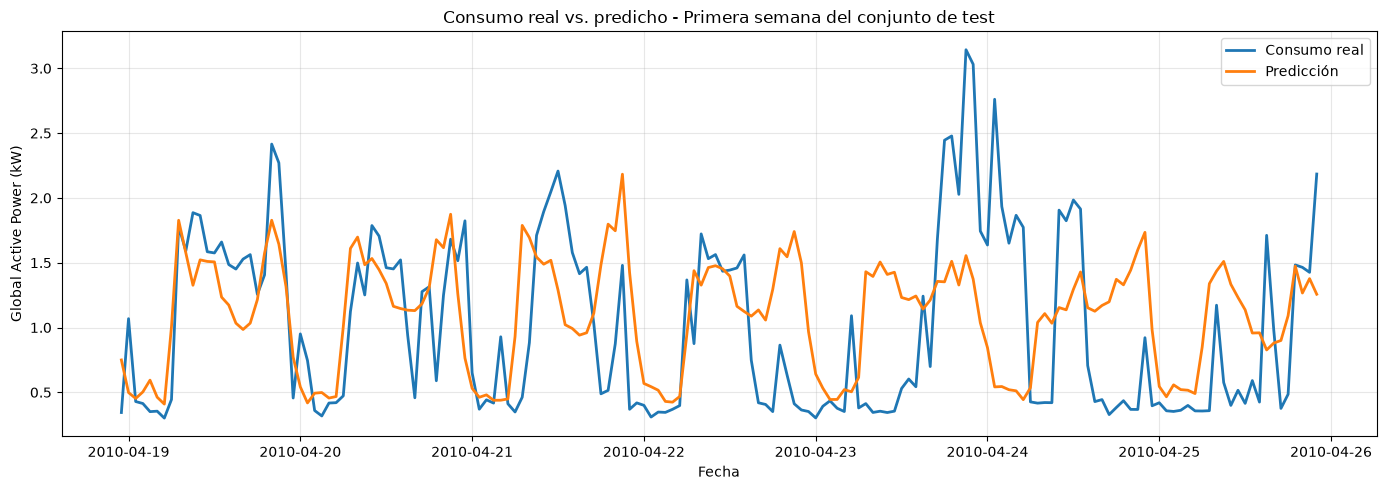

In [14]:
# Primeras 168 horas del conjunto de test = 7 días
n_hours = 168

plt.figure(figsize=(14, 5))

plt.plot(
    y_test.index[:n_hours],
    y_test.iloc[:n_hours],
    label="Consumo real",
    linewidth=2
)

plt.plot(
    y_test.index[:n_hours],
    y_test_pred[:n_hours],
    label="Predicción",
    linewidth=2
)

plt.title("Consumo real vs. predicho - Primera semana del conjunto de test")
plt.xlabel("Fecha")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de las predicciones temporales

La comparación entre los valores reales y las predicciones muestra que el modelo logra capturar parte del comportamiento general y de los ciclos de consumo durante la semana analizada. Las predicciones siguen varias de las subidas y bajadas presentes en la serie real, lo que indica que las variables temporales, los lags y las ventanas móviles aportan información útil para anticipar el consumo con 24 horas de horizonte. Sin embargo, también se observa que las predicciones presentan un comportamiento más suavizado que la serie real. El modelo tiene mayor dificultad para reproducir cambios bruscos y algunos picos elevados de consumo. Por ejemplo, durante el período cercano al 23 y 24 de abril se observan valores reales considerablemente superiores a los estimados por el modelo. Este comportamiento ayuda a explicar que el RMSE (0.5907 kW) sea superior al MAE (0.4314 kW), ya que el RMSE penaliza con mayor intensidad estos errores puntuales de mayor magnitud. Por lo tanto, aunque Random Forest logra representar razonablemente la dinámica general del consumo, los picos y cambios repentinos constituyen una de las principales oportunidades de mejora del modelo.

## 13. Relación entre valores reales y predichos

Para complementar la visualización temporal, se compara cada valor real del conjunto de test con su correspondiente predicción. La línea diagonal representa una predicción perfecta: cuanto más cerca se encuentren los puntos de esta línea, menor será el error del modelo. Esta representación también permite identificar si existen regiones del consumo donde el modelo presenta mayores dificultades.

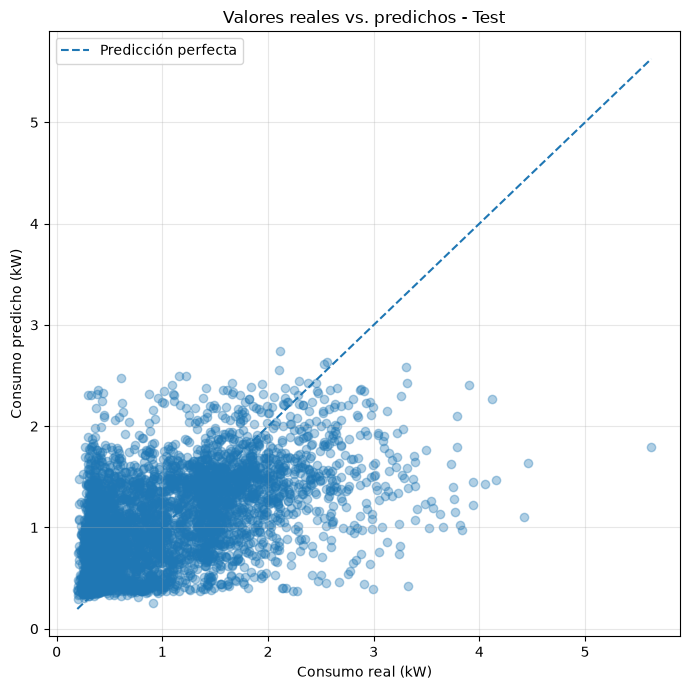

In [15]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.35
)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Predicción perfecta"
)

plt.title("Valores reales vs. predichos - Test")
plt.xlabel("Consumo real (kW)")
plt.ylabel("Consumo predicho (kW)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de valores reales vs. predichos

El gráfico muestra la relación entre los valores reales del consumo y las predicciones realizadas por Random Forest sobre el conjunto de test. La línea diagonal representa el comportamiento de un modelo con predicciones perfectas. Se observa una mayor concentración de predicciones en los niveles bajos y medios de consumo. En los niveles elevados de consumo se observa una mayor presencia de puntos por debajo de la línea de referencia, lo que indica dificultades para reproducir algunos picos de consumo. Sin embargo, este comportamiento no implica necesariamente una tendencia general del modelo a subestimar todas las observaciones, aspecto que se analiza posteriormente mediante los residuos. Este comportamiento coincide con lo observado en la visualización temporal: Random Forest logra representar razonablemente el comportamiento habitual del consumo, pero presenta mayor dificultad ante picos y valores extremos. Por lo tanto, el modelo presenta un desempeño adecuado para capturar el patrón general del consumo con un horizonte de 24 horas, aunque la predicción de picos elevados constituye una de sus principales limitaciones y una posible línea de mejora futura.

## 14. Análisis de residuos

Como complemento a las métricas globales y las visualizaciones anteriores, se analizan los errores de predicción del modelo sobre el conjunto de test. El residuo se define como la diferencia entre el valor real y el valor predicho. Un residuo positivo indica una subestimación del consumo, mientras que un residuo negativo indica una sobreestimación. Este análisis permite identificar posibles sesgos sistemáticos que no son evidentes únicamente mediante MAE y RMSE.

In [16]:
residuals = y_test.to_numpy() - y_test_pred

print("=== ANÁLISIS DE RESIDUOS ===")
print(f"Residuo promedio: {residuals.mean():.4f} kW")
print(f"Mediana:          {np.median(residuals):.4f} kW")
print(f"Desv. estándar:   {residuals.std():.4f} kW")

print()
print(f"Subestimaciones:  {(residuals > 0).mean() * 100:.2f}%")
print(f"Sobreestimaciones:{(residuals < 0).mean() * 100:.2f}%")

=== ANÁLISIS DE RESIDUOS ===
Residuo promedio: -0.0310 kW
Mediana:          -0.0976 kW
Desv. estándar:   0.5899 kW

Subestimaciones:  38.30%
Sobreestimaciones:61.70%


### Interpretación del análisis de residuos

El residuo promedio obtenido fue de **-0.0310 kW**, un valor cercano a cero. Esto indica que el modelo no presenta un sesgo global fuerte hacia la subestimación o la sobreestimación del consumo. La mediana de los residuos fue de **-0.0976 kW** y el **61.70% de las predicciones correspondieron a sobreestimaciones**, frente a un **38.30% de subestimaciones**. Por lo tanto, aunque existe una ligera tendencia a sobreestimar el consumo, la magnitud promedio de este sesgo es reducida. La desviación estándar de los residuos fue de **0.5899 kW**, mostrando que existe variabilidad considerable en los errores individuales. Estos resultados complementan las visualizaciones anteriores. El modelo no subestima sistemáticamente todas las observaciones; sin embargo, sí presenta dificultades particulares para reproducir algunos valores elevados y cambios bruscos del consumo. Por esta razón, el problema observado en los picos debe interpretarse como una limitación localizada y no como un sesgo general de subestimación.

## 15. Conclusiones del modelado

Durante esta etapa se evaluaron diferentes enfoques para pronosticar el consumo eléctrico con un horizonte de **24 horas**. Se comenzó con un baseline estacional basado en el consumo de 24 horas anteriores y posteriormente se evaluaron Regresión Lineal, Random Forest, Gradient Boosting e HistGradientBoosting.

El baseline obtuvo un **MAE de 0.6731 kW** y un **RMSE de 0.9708 kW**, estableciendo el punto de referencia para determinar si los modelos de Machine Learning aportaban una mejora real.

Entre los modelos evaluados, **Random Forest regularizado** presentó el mejor desempeño general. Además de obtener buenos resultados en la validación inicial, su comportamiento fue comprobado mediante **TimeSeriesSplit con cinco particiones temporales**, donde alcanzó un MAE promedio de **0.5227 kW** y un RMSE promedio de **0.7106 kW**, mostrando un desempeño ligeramente superior y más estable que HistGradientBoosting.

Después de seleccionar el modelo, Random Forest fue reentrenado utilizando conjuntamente los datos de entrenamiento y validación y posteriormente evaluado sobre el conjunto de test, que se había mantenido separado durante el proceso de selección. En esta evaluación final obtuvo un **MAE de 0.4314 kW**, un **RMSE de 0.5907 kW** y un **sMAPE de 46.53%**.

En comparación con el baseline, el modelo final logró reducir aproximadamente un **35.9% el MAE** y un **39.2% el RMSE**, demostrando que las variables construidas y el modelo permiten obtener predicciones considerablemente mejores que utilizar únicamente el patrón de consumo de 24 horas anteriores.

El análisis gráfico mostró que el modelo captura adecuadamente el comportamiento general y los patrones habituales del consumo. Sin embargo, presenta mayor dificultad para reproducir algunos **picos elevados y cambios bruscos**, constituyendo esta su principal limitación.

Finalmente, el análisis de residuos mostró un residuo promedio de **-0.0310 kW**, cercano a cero, por lo que no se observa un sesgo global fuerte en las predicciones. Aunque se identificaron errores mayores en determinados períodos de alto consumo, el desempeño general obtenido y su estabilidad durante la validación temporal justifican la selección de **Random Forest regularizado como modelo final** para continuar con las siguientes etapas del pipeline MLOps.